CPU Time: 5.7063305377960205
GPU Time: 2.201730966567993


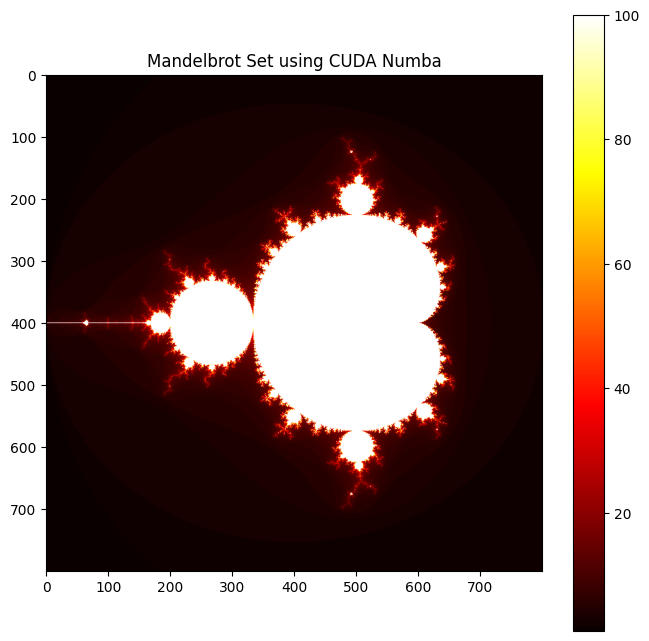

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
import time


# CUDA Kernel
@cuda.jit
def mandelbrot_kernel(min_x, max_x, min_y, max_y, image, max_iter):

    height = image.shape[0]
    width = image.shape[1]

    x, y = cuda.grid(2)

    if x < width and y < height:

        real = min_x + x * (max_x - min_x) / width
        imag = min_y + y * (max_y - min_y) / height

        c_real = real
        c_imag = imag

        z_real = 0.0
        z_imag = 0.0

        count = 0

        while (z_real * z_real + z_imag * z_imag <= 4.0 and count < max_iter):

            temp = z_real * z_real - z_imag * z_imag + c_real
            z_imag = 2.0 * z_real * z_imag + c_imag
            z_real = temp

            count += 1

        image[y, x] = count


# CPU Version
def mandelbrot_cpu(min_x, max_x, min_y, max_y, width, height, max_iter):

    image = np.zeros((height, width), dtype=np.uint8)

    for y in range(height):
        for x in range(width):

            real = min_x + x * (max_x - min_x) / width
            imag = min_y + y * (max_y - min_y) / height

            z_real = 0.0
            z_imag = 0.0

            count = 0

            while (z_real * z_real + z_imag * z_imag <= 4.0 and count < max_iter):

                temp = z_real * z_real - z_imag * z_imag + real
                z_imag = 2.0 * z_real * z_imag + imag
                z_real = temp

                count += 1

            image[y, x] = count

    return image


# Main Program
width = 800
height = 800
max_iter = 100

min_x = -2.0
max_x = 1.0

min_y = -1.5
max_y = 1.5


# CPU Execution
start = time.time()

cpu_image = mandelbrot_cpu(
    min_x, max_x,
    min_y, max_y,
    width, height,
    max_iter
)

cpu_time = time.time() - start

print("CPU Time:", cpu_time)


# GPU Execution
image_gpu = np.zeros((height, width), dtype=np.uint8)

d_image = cuda.to_device(image_gpu)

threadsperblock = (16, 16)

blockspergrid_x = int(np.ceil(width / threadsperblock[0]))
blockspergrid_y = int(np.ceil(height / threadsperblock[1]))

start = time.time()

mandelbrot_kernel[
    (blockspergrid_x, blockspergrid_y),
    threadsperblock
](
    min_x, max_x,
    min_y, max_y,
    d_image,
    max_iter
)

cuda.synchronize()

gpu_time = time.time() - start

gpu_image = d_image.copy_to_host()

print("GPU Time:", gpu_time)


# Display Image
plt.figure(figsize=(8,8))

plt.imshow(gpu_image, cmap='hot')

plt.title("Mandelbrot Set using CUDA Numba")

plt.colorbar()

plt.show()

Clustering Completed
Execution Time: 0.033087730407714844 seconds


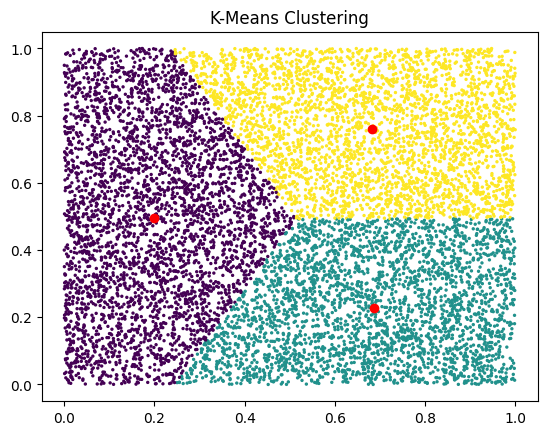

In [2]:
# Parallel K-Means Clustering using CPU

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import time

X = np.random.rand(10000, 2)

start = time.time()

kmeans = KMeans(n_clusters=3, random_state=0)

kmeans.fit(X)

end = time.time()

print("Clustering Completed")
print("Execution Time:", end - start, "seconds")

plt.scatter(X[:,0], X[:,1], c=kmeans.labels_, s=2)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='red')

plt.title("K-Means Clustering")
plt.show()